# 문제 1. 표본조사 체험하기


### 📘 문제

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.


### 📌 아래를 수행해 보세요:

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.


In [ ]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 아래 코드 실행 후, [런타임] - [세션 다시 시작] 필요
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

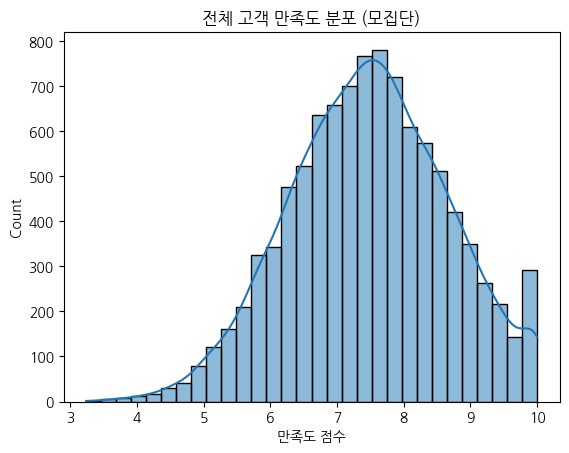

In [ ]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

In [ ]:
#모집단 기초통계 파악
df_pop.describe()

,score
count,10000.000000
mean,7.480611
std,1.181366
min,3.239308
25%,6.674445
50%,7.482919
75%,8.302407
max,10.000000


In [ ]:
# Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.

# 모집단에서 무작위로 30명 추출
sample_30 = np.random.choice(population, size=30, replace=False)

# 표본 평균 계산
sample_mean = sample_30.mean()

print("표본 평균:", sample_mean)

표본 평균: 7.201974814386403


In [ ]:
# Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.

# 난수 생성기 (고정)
np.random.seed(2025)

#저장할 표본 평균의 리스트명 생성
sample_means = []

#표본추출 500번 하기
for _ in range(500):
    sample = np.random.choice(population, size=30, replace=False) # 표본 추출
    sample_means.append(sample.mean()) # 각 표본 평균 계산값은 추가해서 저장

len(sample_means)

500

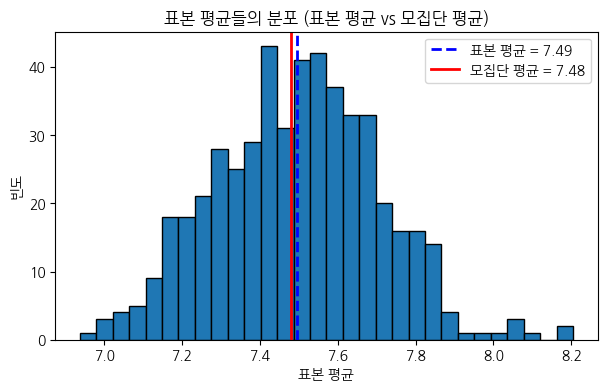

In [ ]:
# Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.


# 평균 계산
sample_mean_value = np.mean(sample_means)   # 표본 평균들의 평균
population_mean = np.mean(population)       # 모집단 평균

plt.figure(figsize=(7, 4))
plt.hist(sample_means, bins=30, edgecolor='black')

# 표본 평균선
plt.axvline(sample_mean_value,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'표본 평균 = {sample_mean_value:.2f}')

# 모집단 평균선
plt.axvline(population_mean,
            color='red',
            linestyle='-',
            linewidth=2,
            label=f'모집단 평균 = {population_mean:.2f}')

plt.xlabel("표본 평균")
plt.ylabel("빈도")
plt.title("표본 평균들의 분포 (표본 평균 vs 모집단 평균)")
plt.legend()
plt.show()

### 🧠 데이터를 어떻게 읽을까요?

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?



*   표본 평균(7.49)들이 모집단 평균(7.48) 중심으로 모임. 여러번 표본을 뽑아 평균 내면 그 평균들의 중심이 모평균과 일치하는 현상을 보여줌.
*   표본 1번 뽑았을 때 7.2 였는데, 500번 반복하니 7.49가 되었음. 1번 표본 뽑는 것은 기대값을 단정짓기엔 불안정한 하나의 값이지만 반복 추출하면 표본 오차 범위(변동성 - 신뢰구간)을 알게되면서 신뢰도가 향상됨.
*  다른 친구가 다른 표본을 뽑았을 때는 비슷하더라도 같은 값이 나오긴 힘들 수 있음. 이것은 무작위 표본 추출 시 서로 다른 데이터를 구성하는 데 따른 확률변수/표본오차 개념으로 자연스럽고 필연적인 현상임
* 표본 평균들의 분포는 반복할 수록 종 모양 정규분포에 가까워지는 중심극한정리의 성질을 보여줌 (표본 크기가 충분히 클수록 평균 분포가 정규분포로 수렴)  

종합적으로 표본 평균들의 분포 중심을 모집단 평균이랑 거의 일치하며 이는 표본 평균이 모집단 평균에 대한 비편향 추정량(추정량의 기댓값의 실제 모수랑 일치하는 성질)임을 보여줌





# 문제 2. 중심극한정리


### 📘 문제

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.


### 📌 아래를 수행해 보세요:

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.


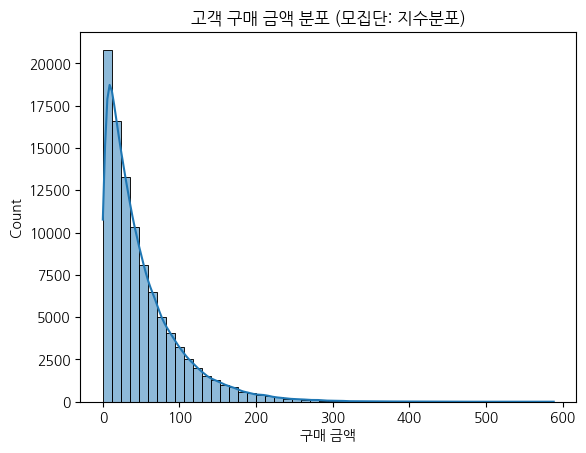

In [ ]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

In [ ]:
# Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

#난수 추출 (재현을 위한 고정)
np.random.seed(2025)

#표본 평균값들 저장할 리스트 생성
sample_means_n5 = []

#1000번 표본 생성 및 평균값 리스트에 추가
for _ in range(1000):
    sample = np.random.choice(population, size=5, replace=False)
    sample_means_n5.append(sample.mean())


In [ ]:
print("표본크기 5일때 평균들의 평균:", np.mean(sample_means_n5))
print("표본크기 5일때 평균들의 표준편차:", np.std(sample_means_n5))

표본크기 5일때 평균들의 평균: 49.56468832083199
표본크기 5일때 평균들의 표준편차: 22.783285231838562


In [ ]:
# Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100

#반복 작업(1000번)에 대한 함수 생성
def sampling_experiment(population, sample_size, n_trials=1000):
    sample_means = []
    sample_stds = []

    for _ in range(n_trials):
        sample = np.random.choice(population, size=sample_size, replace=False)
        sample_means.append(sample.mean()) #표본 평균
        sample_stds.append(sample.std(ddof=1))  # 표본 표준편차

    return {
        "sample_size": sample_size,
        "mean_of_sample_means": np.mean(sample_means), #표본 평균들끼의 평균
        "std_of_sample_means": np.std(sample_means),   #표본 평균들끼리의 표준편자 (데이터의 흔들림)
        "mean_of_sample_stds": np.mean(sample_stds)    #표본 내부 퍼짐 평균 (표준 오차 - 표본 평균 흔들림)
    }


np.random.seed(2025)
result_n5 = sampling_experiment(population, sample_size=5, n_trials=1000)
result_n30 = sampling_experiment(population, sample_size=30, n_trials=1000)
result_n100 = sampling_experiment(population, sample_size=100, n_trials=1000)

def print_result(result):
    print(f"표본 크기 n = {result['sample_size']}")
    print(f"표본 평균들의 평균      : {result['mean_of_sample_means']:.3f}")
    print(f"표본 평균들의 표준편차(SE): {result['std_of_sample_means']:.3f}")
    print(f"표본 표준편차들의 평균   : {result['mean_of_sample_stds']:.3f}")

print_result(result_n5)
print()
print_result(result_n30)
print()  # 줄 한 칸 띄우기
print_result(result_n100)



표본 크기 n = 5
표본 평균들의 평균      : 49.565
표본 평균들의 표준편차(SE): 22.783
표본 표준편차들의 평균   : 42.198

표본 크기 n = 30
표본 평균들의 평균      : 50.378
표본 평균들의 표준편차(SE): 8.964
표본 표준편차들의 평균   : 49.449

표본 크기 n = 100
표본 평균들의 평균      : 50.085
표본 평균들의 표준편차(SE): 4.812
표본 표준편차들의 평균   : 49.510


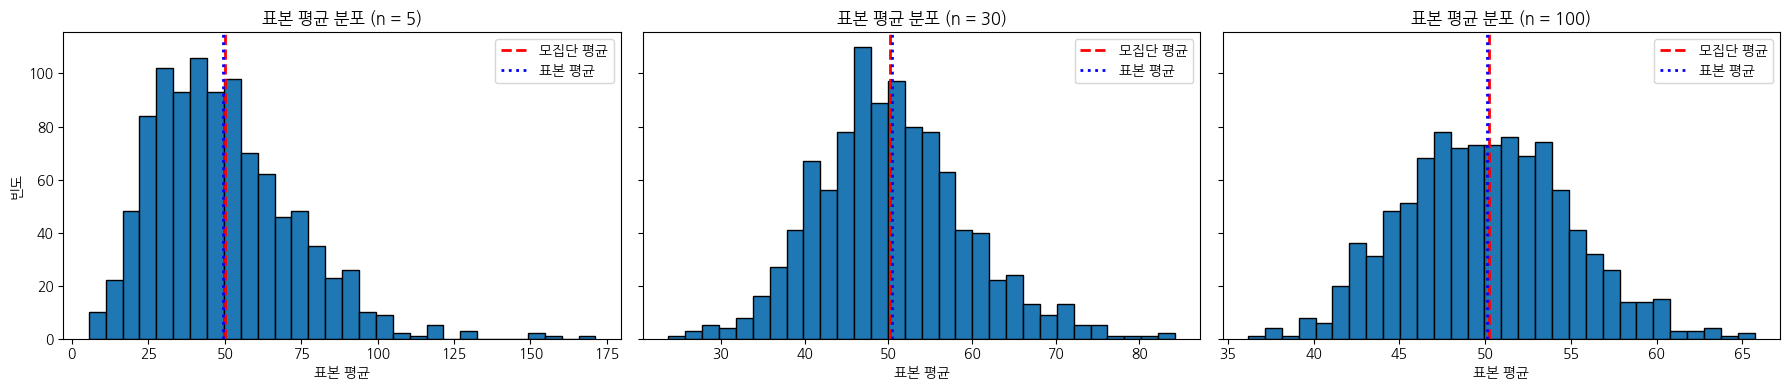

In [ ]:
# Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

#표본평규 리스트 생성
def get_sample_means(population, sample_size, n_trials=1000):
    sample_means = []
    for _ in range(n_trials):
        sample = np.random.choice(population, size=sample_size, replace=False)
        sample_means.append(sample.mean())
    return sample_means

np.random.seed(2025)

sample_means_5 = get_sample_means(population, sample_size=5)
sample_means_30 = get_sample_means(population, sample_size=30)
sample_means_100 = get_sample_means(population, sample_size=100)

pop_mean = population.mean()

#히스토그램 + 평균선 그리기
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

sample_sets = [
    (sample_means_5, 5),
    (sample_means_30, 30),
    (sample_means_100, 100)
]

for ax, (sample_means, n) in zip(axes, sample_sets):
    ax.hist(sample_means, bins=30, edgecolor='black')

    # 모집단 평균선
    ax.axvline(pop_mean,
               color='red',
               linestyle='--',
               linewidth=2,
               label='모집단 평균')

    # 표본 평균들의 평균선
    ax.axvline(np.mean(sample_means),
               color='blue',
               linestyle=':',
               linewidth=2,
               label='표본 평균')

    ax.set_title(f"표본 평균 분포 (n = {n})")
    ax.set_xlabel("표본 평균")
    ax.legend()

axes[0].set_ylabel("빈도")
plt.tight_layout()
plt.show()

### 🧠 데이터를 어떻게 읽을까요?

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?

- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?




*   모집단 평균값에 표본평균의 중심이 위치하고는 있으나, 표본 크기가 작을 때 분포 모양이 다소 비대칭이면서 오른쪽 꼬리가 남아있는 상황임.
*   하지만 표본 크기가 커질수록 대칭형의 종모양(정규분포)에 가까워짐. 중심은 여전히 모집단 평균에 유지됨.
*  원래 모집단을 비대칭이었는데 반복 표본 추출을 통해 극단값의 영향은 줄고 정규분포에 가까운 형태로 변화하기 때문임. (중심극한정리의 성질 때문)
* 이실험을 통해 모집단 분포와 무관하게 표본크기가 커지면 표본평균의 분포는 정규분포로 수렴한다. 즉, 현실 데이터가 완벽하지 않더라도 평균을 이용한 통계 추론이 가능한 이유를 보여준다.
* 표본 크기가 커질수록 분포의 넓이는 좁아짐 (평균의 흔들림이 감소하여 평균추정의 신뢰성이 높아졌다고 할 수 있음.)




# 문제 3. 표준오차


### 📘 문제

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.


### 📌 아래를 수행해 보세요:

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

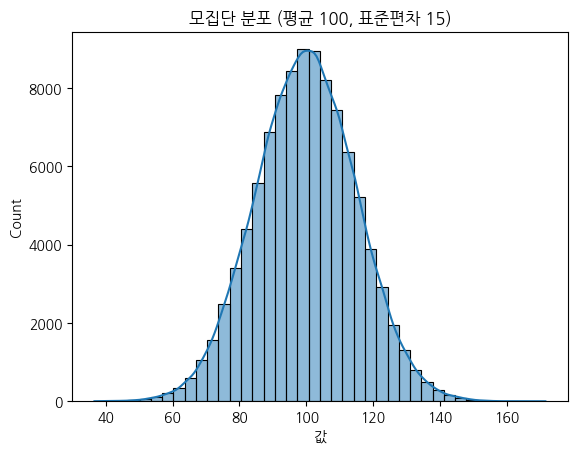

In [ ]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()


In [ ]:
# Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def sampling_summary(population, sample_size, n_trials=1000):
    sample_means = []
    for _ in range(n_trials):
        sample = np.random.choice(population, size=sample_size, replace=False)
        sample_means.append(sample.mean())

    sample_means = np.array(sample_means)

    return {
        "sample_size": sample_size,
        "mean_of_sample_means": sample_means.mean(),   # 표본평균들의 평균
        "std_of_sample_means": sample_means.std(),     # 표본평균분포의 표준편차(=SE, 실험값)
        "SE_theoretical": population.std() / np.sqrt(sample_size)  # 이론값(선택)
    }

np.random.seed(2025)

sample_sizes = [10, 30, 100, 500]
results = [sampling_summary(population, n, n_trials=1000) for n in sample_sizes]

result_df = pd.DataFrame(results).round(4)
result_df

,sample_size,mean_of_sample_means,std_of_sample_means,SE_theoretical
0,10,50.2017,16.3537,15.9128
1,30,50.3781,8.9636,9.1873
2,100,50.0847,4.8119,5.0321
3,500,50.2940,2.1105,2.2504


In [ ]:
# Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

#위에서 도출

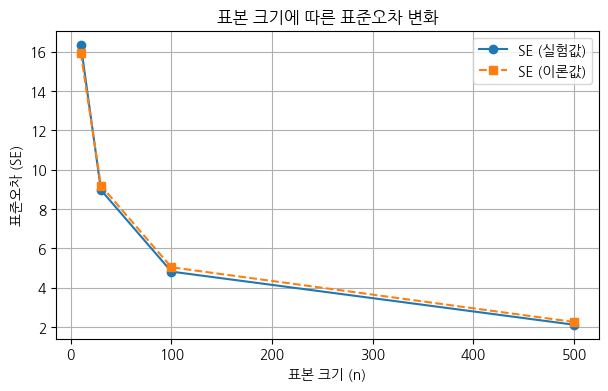

In [ ]:
# Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# 실험값 (시뮬레이션)
plt.plot(
    result_df["sample_size"],
    result_df["std_of_sample_means"],
    marker='o',
    label="SE (실험값)"
)

# 이론값
plt.plot(
    result_df["sample_size"],
    result_df["SE_theoretical"],
    marker='s',
    linestyle='--',
    label="SE (이론값)"
)

plt.xlabel("표본 크기 (n)")
plt.ylabel("표준오차 (SE)")
plt.title("표본 크기에 따른 표준오차 변화")
plt.legend()
plt.grid(True)

plt.show()

### 🧠 데이터를 어떻게 읽을까요?

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?




*   표본 크기가 작을 수록 표본 평균 분포는 넓게 퍼진다. (표본 평균이 불안정)
*   표본 크기가 커질수록 평균 분포가 점점 좁아짐 (표준 오차 감소) 즉 결과에 대한 신뢰도 증가
* 실험값과 이론값은 거의 겹친다. 즉 통계 공식이 실제 데이터에서도 유효하다는 점을 의미함.
*  표본 크기가 많아지면 평균의 변동성이 상쇄되므로 표준 오차가 작아지는 것이다. 즉 데이터가 많을수록 평균의 흔들림을 줄인다.



# 문제 4. 신뢰구간 계산과 해석


### 📘 문제

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.


### 📌 아래를 수행해 보세요:

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.


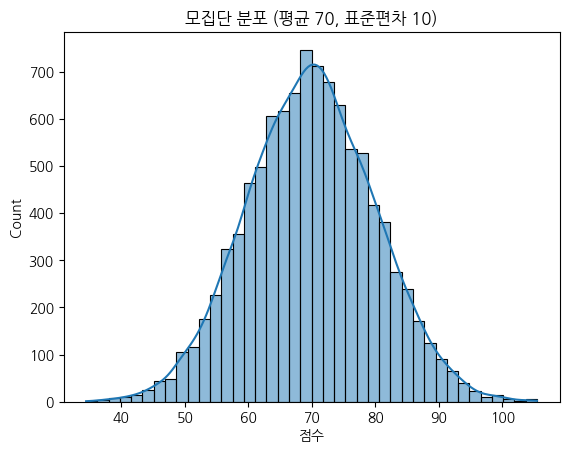

In [ ]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

In [ ]:
# Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.


np.random.seed(2025)

# 1️⃣ 모집단에서 표본 30명 무작위 추출
sample_30 = np.random.choice(population, size=30, replace=False)

# 2️⃣ 표본 평균
sample_mean = sample_30.mean()

# 3️⃣ 표본 표준편차 (표본 기준, ddof=1)
sample_std = sample_30.std(ddof=1)

# 4️⃣ 표준오차 (SE = 표본 표준편차 / √n)
sample_se = sample_std / np.sqrt(len(sample_30))

# 결과 출력
print(f"표본 평균: {sample_mean:.3f}")
print(f"표본 표준편차: {sample_std:.3f}")
print(f"표준오차(SE): {sample_se:.3f}")

표본 평균: 49.777
표본 표준편차: 49.908
표준오차(SE): 9.112


In [ ]:
# Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
import numpy as np
from scipy.stats import norm

np.random.seed(2025)

# 1️⃣ 모집단에서 표본 30명 추출
sample_30 = np.random.choice(population, size=30, replace=False)

# 2️⃣ 표본 평균
sample_mean = sample_30.mean()

# 3️⃣ 모집단 표준편차 (σ)
population_std = population.std()

# 4️⃣ 표준오차 (SE = σ / √n)
se = population_std / np.sqrt(len(sample_30))

# 5️⃣ z 값 (95% 신뢰수준)
z = norm.ppf(0.975)   # = 1.96

# 6️⃣ 신뢰구간 계산
ci_lower = sample_mean - z * se
ci_upper = sample_mean + z * se

# 결과 출력
print(f"표본 평균: {sample_mean:.3f}")
print(f"95% 신뢰구간: ({ci_lower:.3f}, {ci_upper:.3f})")

표본 평균: 49.777
95% 신뢰구간: (31.771, 67.784)


In [ ]:
# Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

import numpy as np
from scipy.stats import t

np.random.seed(2025)

# 1️⃣ 모집단에서 표본 30명 추출
sample_30 = np.random.choice(population, size=30, replace=False)

# 2️⃣ 표본 평균
sample_mean = sample_30.mean()

# 3️⃣ 표본 표준편차 (ddof=1)
sample_std = sample_30.std(ddof=1)

# 4️⃣ 표준오차 (SE = s / √n)
n = len(sample_30)
se = sample_std / np.sqrt(n)

# 5️⃣ 자유도 (df = n - 1)
df = n - 1

# 6️⃣ t 값 (95% 신뢰수준)
t_value = t.ppf(0.975, df)

# 7️⃣ 신뢰구간 계산
ci_lower = sample_mean - t_value * se
ci_upper = sample_mean + t_value * se

# 결과 출력
print(f"표본 평균: {sample_mean:.3f}")
print(f"95% 신뢰구간 (t-분포): ({ci_lower:.3f}, {ci_upper:.3f})")

표본 평균: 49.777
95% 신뢰구간 (t-분포): (31.141, 68.413)


In [ ]:
# Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

import numpy as np
import pandas as pd
from scipy.stats import t

np.random.seed(2025)

# 1️⃣ 표본 추출 (기존과 동일)
sample_30 = np.random.choice(population, size=30, replace=False)

# 2️⃣ 기본 통계량
sample_mean = sample_30.mean()
sample_std = sample_30.std(ddof=1)
n = len(sample_30)
se = sample_std / np.sqrt(n)
df = n - 1

# 3️⃣ 신뢰수준별 계산
confidence_levels = [0.90, 0.95, 0.99]
results = []

for conf in confidence_levels:
    alpha = 1 - conf
    t_value = t.ppf(1 - alpha/2, df)

    ci_lower = sample_mean - t_value * se
    ci_upper = sample_mean + t_value * se
    width = ci_upper - ci_lower

    results.append({
        "confidence_level": f"{int(conf*100)}%",
        "t_value": round(t_value, 3),
        "CI_lower": round(ci_lower, 3),
        "CI_upper": round(ci_upper, 3),
        "CI_width": round(width, 3)
    })

# 4️⃣ 결과 표로 정리
ci_df = pd.DataFrame(results)
ci_df

,confidence_level,t_value,CI_lower,CI_upper,CI_width
0,90%,1.699,34.295,65.260,30.965
1,95%,2.045,31.141,68.413,37.272
2,99%,2.756,24.661,74.893,50.232


### 🧠 데이터를 어떻게 읽을까요?

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?




*   모집단 정보를 모르는 t- 분포 신뢰구간(31.141, 68.413)이 아는 경우인 z- 분포 (31.771, 67.784)보다 더 넓음.  
*   신뢰수준 높아지면 신뢰구간의 폭은 더 커짐. (더 확실하게 포함하려면 더 넓은 구간을 감수)
* 신뢰구간이 넓다는 것은 평균 추정의 불확실성이 큰 경우에 해당하고 신뢰구간이 적다는 것은 평균 추정이 상대적으로 정밀하다는 의미임. 따라서 신뢰구간이 적을수록 의사결정에 활용하기 좋다.
* 일단 95%의 신뢰구간이 31.1, 68.4이므로 모평균의 만족도는 이 범위 안에 있을 가능성이 높음. 신뢰구간으로 마케팅 전략에 적용할 수 있는 포인트는 고객 만족도의 불확실성과 리스크를 어떻게 볼 것인가다. 따라서 신뢰구간이 넓으면 표본수를 좀 더 늘려서 고객 만족도에서의 변동치들을 관리할 수 있는 방안을 찾을 것 같다. (극단값 쪽의 고객관리나, 좀 더 테스트를 많이 해서 표본수를 높이는 방향 제안)




# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정


### 📘 문제

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.


### 📌 아래를 수행해 보세요:

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.


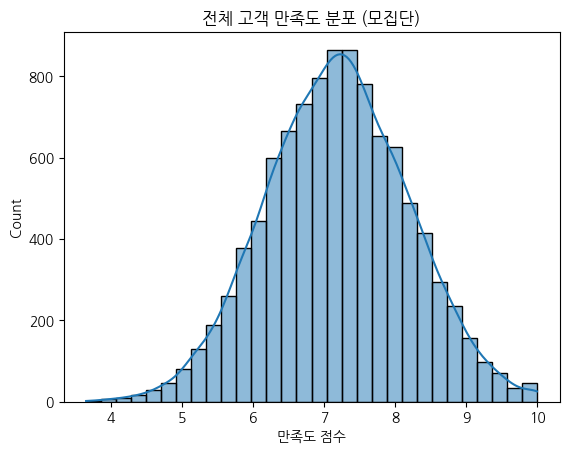

In [ ]:
# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)  #모집단 평균 7.2, 표준편차 1, 고객 만명 전체
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

In [ ]:
# Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.

import numpy as np

np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)  #모집단 평균 7.2, 표준편차 1, 고객 만명 전체
population = np.clip(population, 1, 10)


# 모집단에서 표본 40명을 무작위 추출
sample_40 = np.random.choice(population, size=40, replace=False)

# 표본 평균
sample_mean_40 = sample_40.mean()

# 표본 표준편차
sample_std_40 = sample_40.std(ddof=1)

# 결과 출력
print(f"표본 평균: {sample_mean_40:.3f}")
print(f"표본 표준편차: {sample_std_40:.3f}")


표본 평균: 7.144
표본 표준편차: 1.099


In [ ]:
# Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
import numpy as np
from scipy.stats import t

# 1️⃣ 표본 크기
n = len(sample_40)

# 2️⃣ 표준오차(SE) 계산
# SE = 표본 표준편차 / √n
se_40 = sample_std_40 / np.sqrt(n)

# 3️⃣ 자유도 (df = n - 1)
df = n - 1

# 4️⃣ t-분포 임계값 (95% 신뢰수준, 양측)
t_value = t.ppf(0.975, df)

# 5️⃣ 95% 신뢰구간 계산
ci_lower = sample_mean_40 - t_value * se_40
ci_upper = sample_mean_40 + t_value * se_40

# 결과 출력
print(f"표준오차(SE): {se_40:.3f}")
print(f"95% 신뢰구간: ({ci_lower:.3f}, {ci_upper:.3f})")

표준오차(SE): 0.174
95% 신뢰구간: (6.793, 7.496)


* 표준오차가 비교적 작게 나타나 표본 평균이 모평균을 안정적으로 추정하는 것으로 보임.

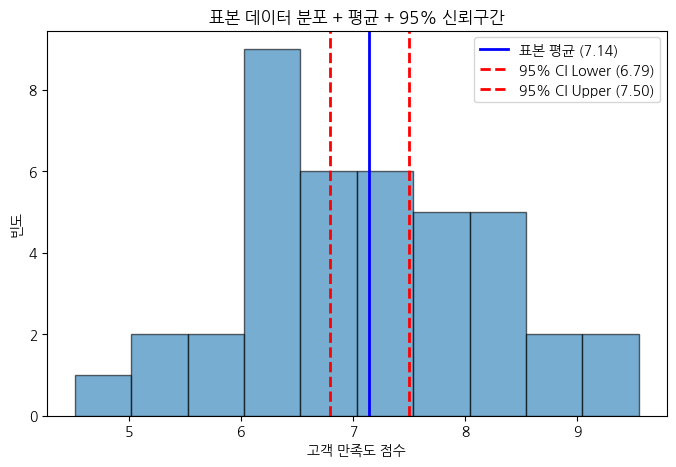

In [ ]:
# Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# 1️⃣ 표본 데이터 히스토그램
plt.hist(sample_40, bins=10, edgecolor='black', alpha=0.6)

# 2️⃣ 표본 평균선
plt.axvline(sample_mean_40,
            color='blue',
            linewidth=2,
            label=f"표본 평균 ({sample_mean_40:.2f})")

# 3️⃣ 95% 신뢰구간 하한 / 상한
plt.axvline(ci_lower,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"95% CI Lower ({ci_lower:.2f})")

plt.axvline(ci_upper,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"95% CI Upper ({ci_upper:.2f})")

# 4️⃣ 그래프 설정
plt.title("표본 데이터 분포 + 평균 + 95% 신뢰구간")
plt.xlabel("고객 만족도 점수")
plt.ylabel("빈도")
plt.legend()
plt.show()

In [ ]:
# Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?

- 아래 데이터를 읽는 질문에 대한 답변을 먼저 확인 한 후 고민해보기



*   평균보다는 신뢰구간의 하한값을 검토하여 불만가능성을 끌어올릴 수 있는 방안을 모색해본다.  (현재 평균값 7.14, 하한값 6.79임)
*   평균이 7점 이상이므로 만족도가 중상위권으로 읽힘. 평균과 그 이상의 고객층은 락인 전략을 추진한다. (예를 들어 충분히 만족하고 있는 고객에세 신규 친구 추천하면 리워드를 주는 마케팅 등 긍정 경험 확산을 시키는 방향으로 추진)
* 두번째로는 불만 가능한 고객의 리스크 관리 전략이 뒤따라야 한다. 만족도 6점 이하 고객에게는 그 이유를 쓰게 해서 불만 포인트를 점검하여 해소하는 것이 필요하다. 그리고 해소가 된 후에는 다시 알림을 통해 개선 경험을 시키고 번거롭게  한 것에 대한 보상 포인트를 제공한다.
* 그 외 표본수를 좀 더 늘리기 위해서 설문 표본을 확장하고, 정기적인 만족도 트래킹을 실시한다.



### 🧠 데이터를 어떻게 읽을까요?

- 신뢰구간은 몇 점에서 몇 점 사이인가요?

- 이 구간은 전체 모집단 평균을 포함하고 있나요?

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?




*   신뢰구간은 6.79에서 7.50으로 나옴.
*   해당 구간은 전체 모집단 평균인 7.2점을 포함하고 있음.
* 이 결과는 고객 만족도가 충분히 높다 말할 수 있나? 하한점이 6.79이라서 평균값 자체는 7점이상이라 괜찮아보이지만 일부 고객 불만 가능성을 고려해야 한다고 생각함.
* 신뢰구간의 넓고 좁음은 상대적인 개념인것 같지만 일단 표본 크기가 40이고, 만족도 척도가 10이고 신뢰구간폭이 0.71임을 보았을 때 만족도 척도의 약 7%폭에 해당하므로 의사결정은 어느정도 가능하다고 생각하는 범위라고 생각함. 신뢰구간이 넓다면 표본수를 늘리던지 전체 평균 대신 고객을 세분화하여 분석하는 방법으로 분석의 정확도와 신뢰도를 높일 수 있을 것임.
